# GreenPulse — Full EDA for HRZSI Tropical Soil Dataset

This notebook performs a complete exploratory data analysis for the **GreenPulse anomaly-detection pipeline**.

### Dataset source used
The analysis reads the `Object_df_raw` sheet from the HRZSI workbook and focuses on the seven variables selected for GreenPulse:

- `DATE`
- `Air temperature (°C)`
- `Relative humidity (%)`
- `SMC1`
- `Ts1`
- `SMC2`
- `Ts2`

### Layer meaning
- **Layer 1:** 0–10 cm
- **Layer 2:** 10–42 cm

### Why only these columns?
The intended GreenPulse model uses:
- air temperature,
- relative humidity,
- soil temperature,
- soil moisture.

Rainfall, solar irradiance, Layer 3, and the original HRZSI-derived variables are excluded from the first model so that the training inputs match the planned GreenPulse sensor system more closely.

### EDA goals
This notebook investigates:
1. dataset shape and structure,
2. timestamp quality and sampling interval,
3. missing values and duplicates,
4. descriptive statistics,
5. distributions and extreme values,
6. correlations,
7. Layer 1 vs Layer 2 behaviour,
8. temporal and seasonal patterns,
9. rate-of-change behaviour,
10. anomaly-oriented diagnostics,
11. chronological train/validation/test boundaries,
12. preparation for a generic four-feature soil-condition model.

> **Important:** EDA should identify suspicious observations, not automatically delete them. Final cleaning decisions belong in `preprocess.py`.

## 1. Imports and configuration

In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## 2. Locate and load the workbook

In [5]:
# Expected project layout:
#
# ml/
# ├── notebooks/
# │   └── EDA.ipynb
# └── data/
#     └── raw/
#         └── <HRZSI workbook>.xlsx

RAW_DIR = Path("../data/raw")
RESULTS_DIR = Path("../results/eda")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

candidate_names = [
    "hrzsi_dataset_and_analysis-1-1-object_df_raw.xlsx",
    "HRZSI_Dataset_and_Analysis (1).xlsx",
    "HRZSI_Dataset_and_Analysis.xlsx",
]

data_file = None

for name in candidate_names:
    path = RAW_DIR / name
    if path.exists():
        data_file = path
        break

# Fallback: use the first xlsx file in data/raw
if data_file is None:
    xlsx_files = sorted(RAW_DIR.glob("*.xlsx"))
    if not xlsx_files:
        raise FileNotFoundError(
            "No .xlsx file found in ../data/raw/"
        )
    data_file = xlsx_files[0]

print("Using file:", data_file)

Using file: ../data/raw/hrzsi_dataset_and_analysis.xlsx


In [6]:
excel_file = pd.ExcelFile(data_file)

print("Workbook sheets:")
print(excel_file.sheet_names[:15], "..." if len(excel_file.sheet_names) > 15 else "")

if "Object_df_raw" in excel_file.sheet_names:
    sheet_name = "Object_df_raw"
else:
    # Useful if you exported only the raw sheet into a separate workbook.
    sheet_name = excel_file.sheet_names[0]

print("Using sheet:", sheet_name)

raw_df = pd.read_excel(
    data_file,
    sheet_name=sheet_name
)

print("Raw shape:", raw_df.shape)
display(raw_df.head())

Workbook sheets:
['Object_df_raw'] 
Using sheet: Object_df_raw
Raw shape: (5426, 25)


,DATE,Air temperature (°C),Relative humidity (%),Solar irradiance (lux),SMC1,Ts1,SMC2,Ts2,SMC3,Ts3,Rainfall,v_theta1,v_theta2,v_theta3,HIC,VHGI,C_HT,VBC,HHRC,MAC,TLC,HRZSI,Stable,Stable_group,Group
0,2023-02-03 11:00:00.000,30.130,80.170,819.200,35.483,26.777,46.483,26.680,43.440,26.347,0.000,0.221,0.207,0.003,0.428,-13.884,0.000,8.053,0.531,0.720,0.000,2.174,False,0.576,1
1,2023-02-03 12:00:00.000,29.830,81.600,916.910,35.410,26.680,46.533,26.497,43.440,26.295,0.000,0.221,0.207,0.003,0.428,-13.821,1.653,8.016,0.530,0.722,0.000,2.174,False,0.805,1
2,2023-02-03 12:59:59.999,30.500,78.650,"1,536.000",35.400,26.650,46.562,26.394,43.432,26.290,0.000,0.181,0.178,0.003,0.359,-13.770,1.739,7.987,0.530,0.723,0.000,2.162,False,1.025,1
3,2023-02-03 14:00:00.000,30.190,79.900,754.180,35.310,26.698,46.566,26.334,43.440,26.272,1.000,0.140,0.150,0.002,0.290,-13.730,1.875,7.964,0.529,0.724,0.000,2.151,False,1.236,1
4,2023-02-03 15:00:00.000,27.820,95.630,413.870,35.388,26.815,46.590,26.318,43.433,26.255,2.000,0.100,0.121,0.002,0.221,-13.702,2.119,7.947,0.529,0.725,0.000,2.143,False,1.438,1


## 3. Select only the GreenPulse columns

In [7]:
SELECTED_COLUMNS = [
    "DATE",
    "Air temperature (°C)",
    "Relative humidity (%)",
    "SMC1",
    "Ts1",
    "SMC2",
    "Ts2",
]

missing_columns = [
    col for col in SELECTED_COLUMNS
    if col not in raw_df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

df = raw_df[SELECTED_COLUMNS].copy()

df = df.rename(columns={
    "DATE": "timestamp",
    "Air temperature (°C)": "air_temp_c",
    "Relative humidity (%)": "humidity",
    "SMC1": "soil_moisture_l1",
    "Ts1": "soil_temp_l1_c",
    "SMC2": "soil_moisture_l2",
    "Ts2": "soil_temp_l2_c",
})

display(df.head())
print("Selected shape:", df.shape)

,timestamp,air_temp_c,humidity,soil_moisture_l1,soil_temp_l1_c,soil_moisture_l2,soil_temp_l2_c
0,2023-02-03 11:00:00.000,30.130,80.170,35.483,26.777,46.483,26.680
1,2023-02-03 12:00:00.000,29.830,81.600,35.410,26.680,46.533,26.497
2,2023-02-03 12:59:59.999,30.500,78.650,35.400,26.650,46.562,26.394
3,2023-02-03 14:00:00.000,30.190,79.900,35.310,26.698,46.566,26.334
4,2023-02-03 15:00:00.000,27.820,95.630,35.388,26.815,46.590,26.318


Selected shape: (5426, 7)


## 4. Parse timestamp and numeric columns

In [8]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

SENSOR_COLUMNS = [
    "air_temp_c",
    "humidity",
    "soil_moisture_l1",
    "soil_temp_l1_c",
    "soil_moisture_l2",
    "soil_temp_l2_c",
]

for col in SENSOR_COLUMNS:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df = (
    df.sort_values("timestamp")
      .reset_index(drop=True)
)

display(df.head())
display(df.dtypes.to_frame("dtype"))

,timestamp,air_temp_c,humidity,soil_moisture_l1,soil_temp_l1_c,soil_moisture_l2,soil_temp_l2_c
0,2023-02-03 11:00:00.000,30.130,80.170,35.483,26.777,46.483,26.680
1,2023-02-03 12:00:00.000,29.830,81.600,35.410,26.680,46.533,26.497
2,2023-02-03 12:59:59.999,30.500,78.650,35.400,26.650,46.562,26.394
3,2023-02-03 14:00:00.000,30.190,79.900,35.310,26.698,46.566,26.334
4,2023-02-03 15:00:00.000,27.820,95.630,35.388,26.815,46.590,26.318


,dtype
timestamp,datetime64[ns]
air_temp_c,float64
humidity,float64
soil_moisture_l1,float64
soil_temp_l1_c,float64
soil_moisture_l2,float64
soil_temp_l2_c,float64


## 5. Dataset overview

In [9]:
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

duration = (
    df["timestamp"].max()
    - df["timestamp"].min()
)

print("Monitoring duration:", duration)
print()
print(df.info())

DATASET OVERVIEW
Rows: 5426
Columns: 7
Start: 2023-02-03 11:00:00
End: 2023-09-17 12:00:00
Monitoring duration: 226 days 01:00:00

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5426 entries, 0 to 5425
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         5426 non-null   datetime64[ns]
 1   air_temp_c        5426 non-null   float64       
 2   humidity          5426 non-null   float64       
 3   soil_moisture_l1  5426 non-null   float64       
 4   soil_temp_l1_c    5426 non-null   float64       
 5   soil_moisture_l2  5426 non-null   float64       
 6   soil_temp_l2_c    5426 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 296.9 KB
None


## 6. Timestamp quality and duplicate analysis

In [10]:
invalid_timestamps = df["timestamp"].isna().sum()
duplicate_rows = df.duplicated().sum()
duplicate_timestamps = df["timestamp"].duplicated().sum()

timestamp_quality = pd.DataFrame({
    "metric": [
        "Invalid timestamps",
        "Duplicate full rows",
        "Duplicate timestamps",
    ],
    "count": [
        invalid_timestamps,
        duplicate_rows,
        duplicate_timestamps,
    ],
})

display(timestamp_quality)

,metric,count
0,Invalid timestamps,0
1,Duplicate full rows,0
2,Duplicate timestamps,0


## 7. Sampling interval and time gaps

In [11]:
time_diff_hours = (
    df["timestamp"]
      .diff()
      .dt.total_seconds()
      .div(3600)
)

print("Most common sampling intervals (hours):")
display(
    time_diff_hours
    .value_counts(dropna=True)
    .head(10)
    .to_frame("count")
)

sampling_summary = pd.DataFrame({
    "median_interval_hours": [time_diff_hours.median()],
    "mean_interval_hours": [time_diff_hours.mean()],
    "min_interval_hours": [time_diff_hours.min()],
    "max_interval_hours": [time_diff_hours.max()],
    "gaps_over_1_5_hours": [(time_diff_hours > 1.5).sum()],
    "gaps_over_3_hours": [(time_diff_hours > 3).sum()],
    "gaps_over_24_hours": [(time_diff_hours > 24).sum()],
})

display(sampling_summary.round(3))

Most common sampling intervals (hours):


,count
timestamp,
1.000,1809
1.000,1808
1.000,1808


,median_interval_hours,mean_interval_hours,min_interval_hours,max_interval_hours,gaps_over_1_5_hours,gaps_over_3_hours,gaps_over_24_hours
0,1.000,1.000,1.000,1.000,0,0,0


In [12]:
large_gaps = df.loc[
    time_diff_hours > 1.5,
    ["timestamp"]
].copy()

large_gaps["gap_hours"] = time_diff_hours[
    time_diff_hours > 1.5
].values

print("Number of gaps > 1.5 hours:", len(large_gaps))
display(large_gaps.head(20))

Number of gaps > 1.5 hours: 0


,timestamp,gap_hours


## 8. Missing-value analysis

In [13]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
    "available_count": df.notna().sum(),
}).sort_values(
    "missing_percent",
    ascending=False
)

display(missing_summary.round(3))

missing_summary.to_csv(
    RESULTS_DIR / "missing_value_summary.csv"
)

,missing_count,missing_percent,available_count
timestamp,0,0.000,5426
air_temp_c,0,0.000,5426
humidity,0,0.000,5426
soil_moisture_l1,0,0.000,5426
soil_temp_l1_c,0,0.000,5426
soil_moisture_l2,0,0.000,5426
soil_temp_l2_c,0,0.000,5426


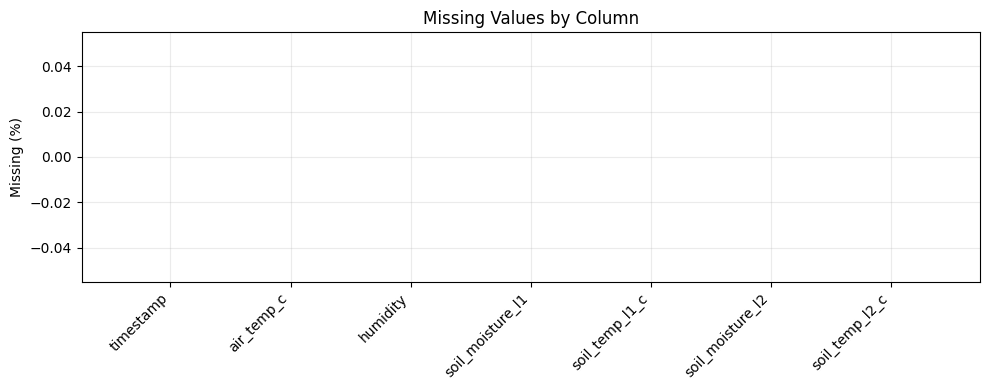

In [14]:
plt.figure(figsize=(10, 4))
plt.bar(
    missing_summary.index,
    missing_summary["missing_percent"]
)
plt.ylabel("Missing (%)")
plt.title("Missing Values by Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Descriptive statistics

In [15]:
descriptive_stats = df[
    SENSOR_COLUMNS
].describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
).T

display(descriptive_stats.round(3))

descriptive_stats.to_csv(
    RESULTS_DIR / "descriptive_statistics.csv"
)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
air_temp_c,"5,426.000",27.753,3.306,20.650,22.100,23.042,23.630,24.870,27.100,30.700,32.600,33.300,33.518,34.800
humidity,"5,426.000",87.101,14.036,10.500,58.370,64.970,66.300,75.000,92.125,99.900,99.900,99.900,99.900,99.900
soil_moisture_l1,"5,426.000",30.408,4.569,16.533,17.540,20.510,24.840,28.091,30.840,32.992,35.630,37.190,39.240,45.042
soil_temp_l1_c,"5,426.000",27.478,0.805,25.720,25.967,26.203,26.410,26.882,27.460,28.050,28.540,28.768,29.483,30.680
soil_moisture_l2,"5,426.000",39.168,6.511,18.925,20.250,26.460,29.243,34.920,41.370,44.107,45.966,46.442,46.985,47.260
soil_temp_l2_c,"5,426.000",27.183,0.533,26.087,26.228,26.390,26.498,26.777,27.170,27.528,27.793,28.080,28.740,29.265


## 10. Unique-value and constant-value checks

In [16]:
unique_summary = pd.DataFrame({
    "unique_values": df[SENSOR_COLUMNS].nunique(),
    "zero_count": (df[SENSOR_COLUMNS] == 0).sum(),
    "zero_percent": (df[SENSOR_COLUMNS] == 0).mean() * 100,
})

display(unique_summary.round(3))

,unique_values,zero_count,zero_percent
air_temp_c,926,0,0.000
humidity,1059,0,0.000
soil_moisture_l1,1468,0,0.000
soil_temp_l1_c,1488,0,0.000
soil_moisture_l2,1575,0,0.000
soil_temp_l2_c,1209,0,0.000


## 11. Broad physical-range sanity checks

In [17]:
# These are diagnostic limits, not automatic cleaning rules.

VALID_RANGES = {
    "air_temp_c": (0, 50),
    "humidity": (0, 100),
    "soil_moisture_l1": (0, 100),
    "soil_temp_l1_c": (0, 50),
    "soil_moisture_l2": (0, 100),
    "soil_temp_l2_c": (0, 50),
}

range_rows = []

for col, (lower, upper) in VALID_RANGES.items():
    valid = df[col].notna()
    outside = valid & ~df[col].between(lower, upper)

    range_rows.append({
        "feature": col,
        "observed_min": df[col].min(),
        "observed_max": df[col].max(),
        "diagnostic_min": lower,
        "diagnostic_max": upper,
        "outside_count": int(outside.sum()),
        "outside_percent": (
            outside.sum() / valid.sum() * 100
            if valid.sum() else np.nan
        ),
    })

range_summary = pd.DataFrame(range_rows)
display(range_summary.round(3))

,feature,observed_min,observed_max,diagnostic_min,diagnostic_max,outside_count,outside_percent
0,air_temp_c,20.650,34.800,0,50,0,0.000
1,humidity,10.500,99.900,0,100,0,0.000
2,soil_moisture_l1,16.533,45.042,0,100,0,0.000
3,soil_temp_l1_c,25.720,30.680,0,50,0,0.000
4,soil_moisture_l2,18.925,47.260,0,100,0,0.000
5,soil_temp_l2_c,26.087,29.265,0,50,0,0.000


## 12. IQR extreme-value diagnostics

For anomaly detection, **do not automatically remove these observations**.  
This section only identifies values that are statistically far from the central distribution.

In [18]:
iqr_rows = []

for col in SENSOR_COLUMNS:
    s = df[col].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    extreme_mask = (
        (s < lower)
        | (s > upper)
    )

    iqr_rows.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "extreme_count": int(extreme_mask.sum()),
        "extreme_percent": extreme_mask.mean() * 100,
    })

iqr_summary = pd.DataFrame(iqr_rows)
display(iqr_summary.round(3))

iqr_summary.to_csv(
    RESULTS_DIR / "iqr_extreme_summary.csv",
    index=False
)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,extreme_count,extreme_percent
0,air_temp_c,24.870,30.700,5.830,16.125,39.445,0,0.000
1,humidity,75.000,99.900,24.900,37.650,137.250,14,0.258
2,soil_moisture_l1,28.091,32.992,4.901,20.740,40.343,317,5.842
3,soil_temp_l1_c,26.882,28.050,1.168,25.131,29.801,33,0.608
4,soil_moisture_l2,34.920,44.107,9.187,21.140,57.887,74,1.364
5,soil_temp_l2_c,26.777,27.528,0.752,25.649,28.656,65,1.198


## 13. Distribution plots

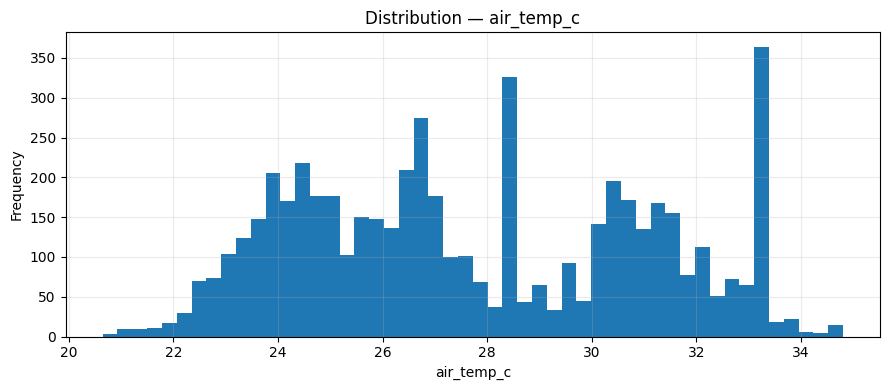

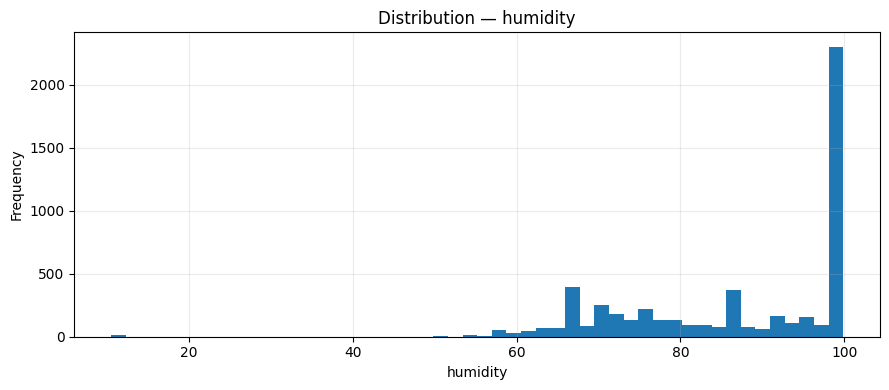

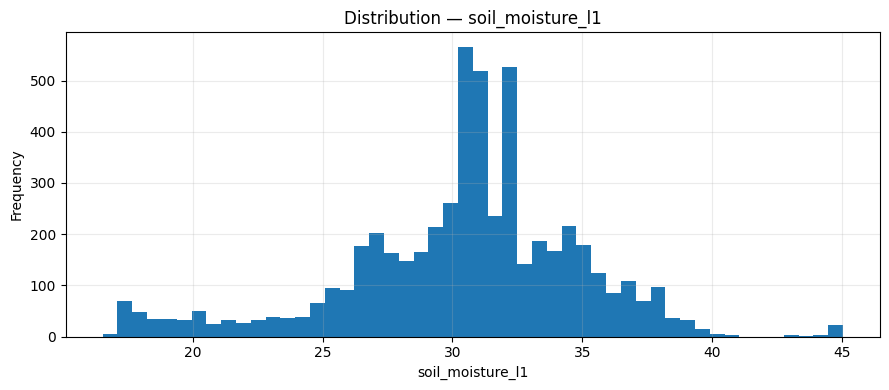

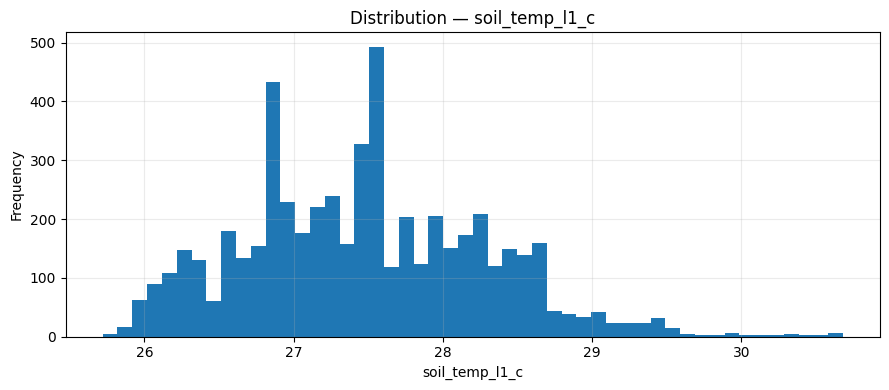

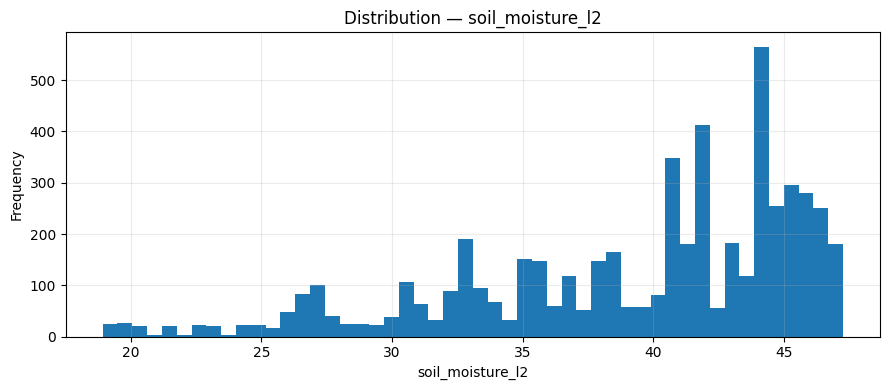

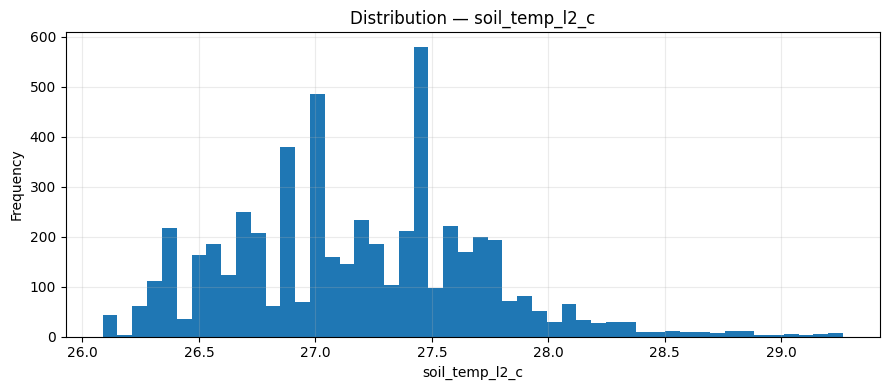

In [19]:
for col in SENSOR_COLUMNS:
    plt.figure(figsize=(9, 4))
    plt.hist(
        df[col].dropna(),
        bins=50
    )
    plt.title(f"Distribution — {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 14. Boxplots

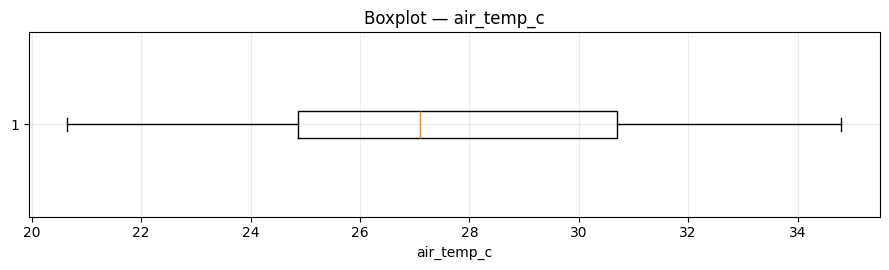

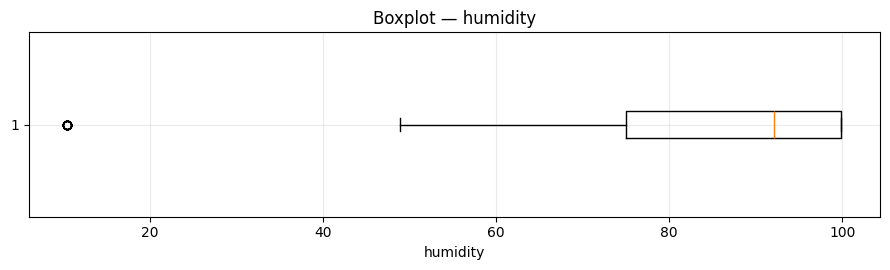

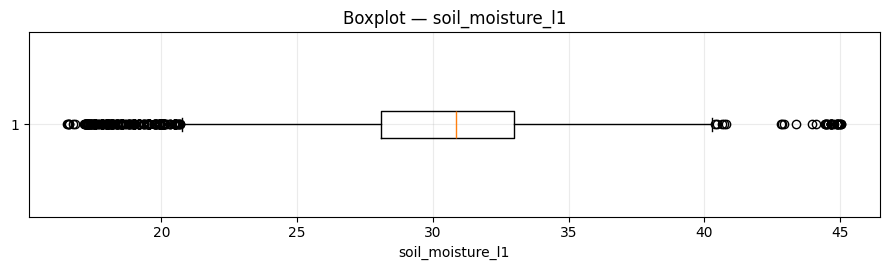

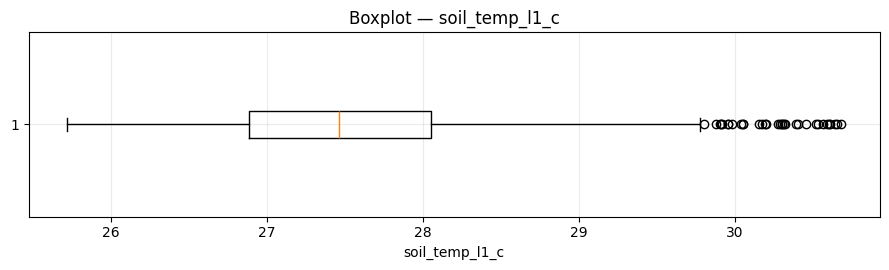

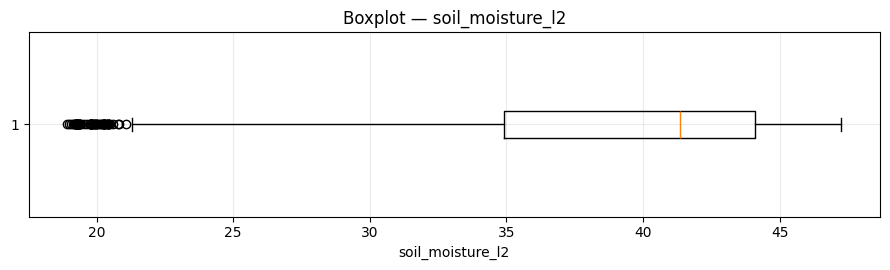

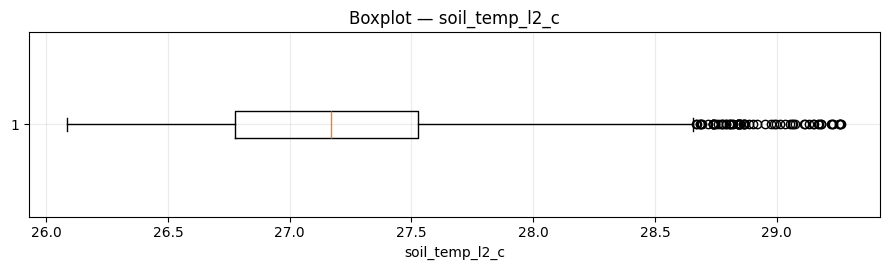

In [20]:
for col in SENSOR_COLUMNS:
    plt.figure(figsize=(9, 2.8))
    plt.boxplot(
        df[col].dropna(),
        vert=False
    )
    plt.title(f"Boxplot — {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## 15. Correlation matrix

,air_temp_c,humidity,soil_moisture_l1,soil_temp_l1_c,soil_moisture_l2,soil_temp_l2_c
air_temp_c,1.000,-0.826,-0.050,-0.314,0.013,-0.226
humidity,-0.826,1.000,0.115,0.301,0.058,0.196
soil_moisture_l1,-0.050,0.115,1.000,-0.382,0.951,-0.467
soil_temp_l1_c,-0.314,0.301,-0.382,1.000,-0.349,0.893
soil_moisture_l2,0.013,0.058,0.951,-0.349,1.000,-0.425
soil_temp_l2_c,-0.226,0.196,-0.467,0.893,-0.425,1.000


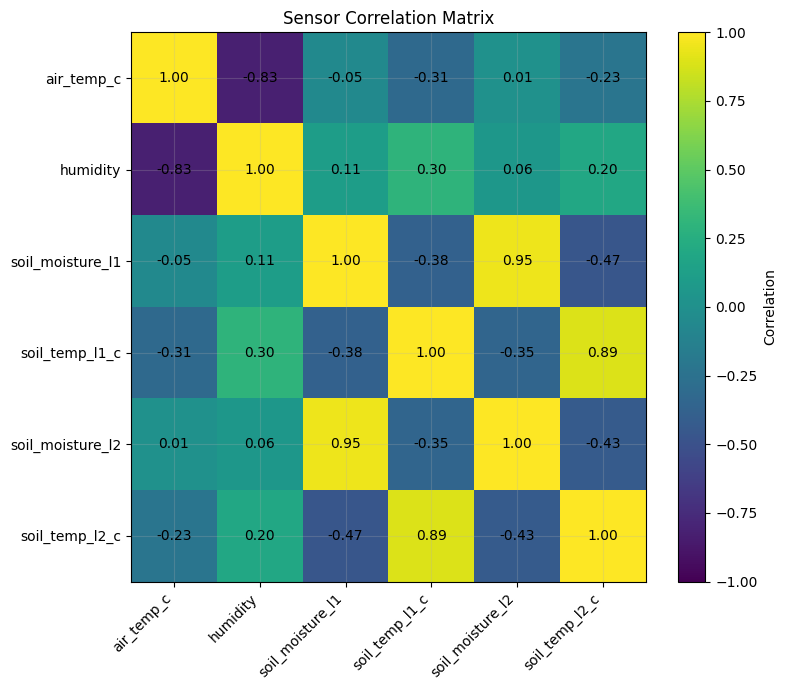

In [21]:
corr = df[
    SENSOR_COLUMNS
].corr()

display(corr.round(3))

fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(
    corr,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(
    range(len(SENSOR_COLUMNS))
)
ax.set_yticks(
    range(len(SENSOR_COLUMNS))
)

ax.set_xticklabels(
    SENSOR_COLUMNS,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    SENSOR_COLUMNS
)

for i in range(len(SENSOR_COLUMNS)):
    for j in range(len(SENSOR_COLUMNS)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(
    image,
    ax=ax,
    label="Correlation"
)

plt.title(
    "Sensor Correlation Matrix"
)
plt.tight_layout()
plt.show()

## 16. Full time-series plots

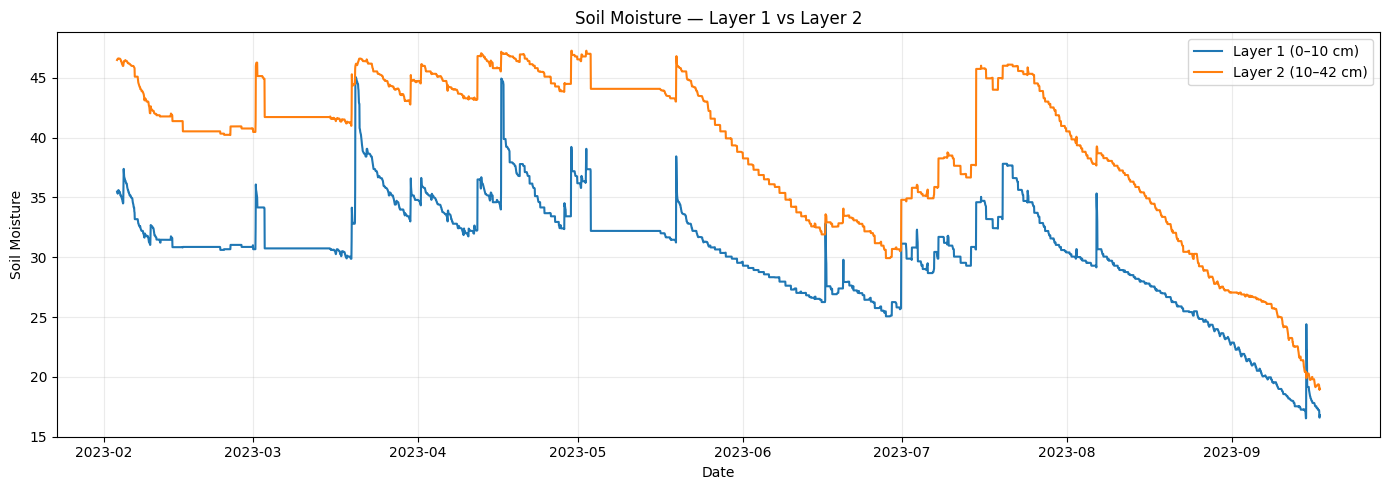

In [22]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["soil_moisture_l1"],
    label="Layer 1 (0–10 cm)"
)

plt.plot(
    df["timestamp"],
    df["soil_moisture_l2"],
    label="Layer 2 (10–42 cm)"
)

plt.ylabel("Soil Moisture")
plt.xlabel("Date")
plt.title(
    "Soil Moisture — Layer 1 vs Layer 2"
)
plt.legend()
plt.tight_layout()
plt.show()

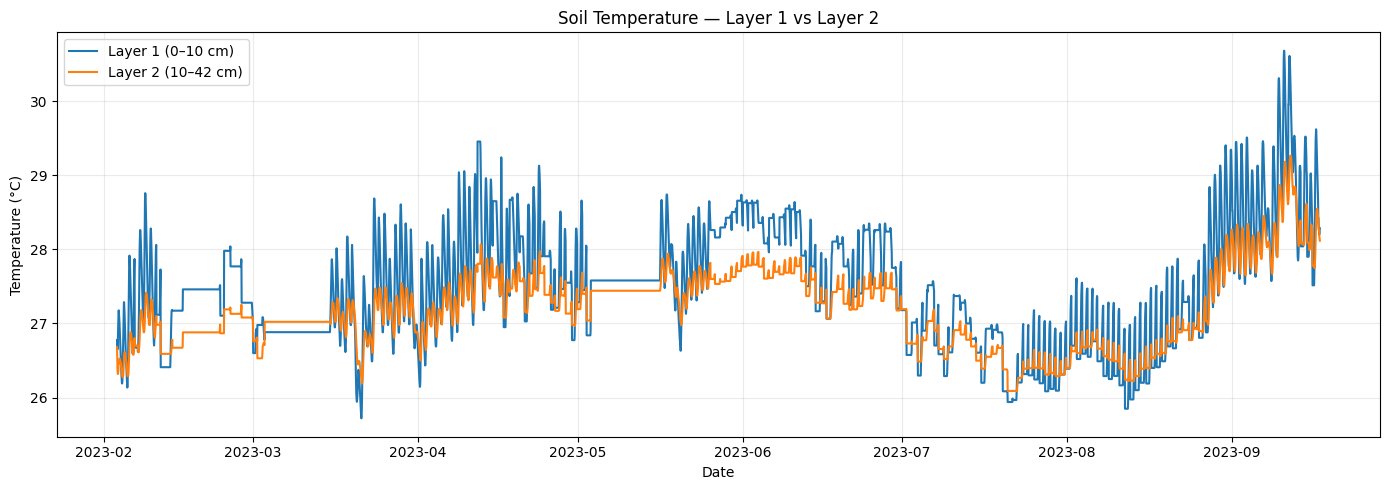

In [23]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["soil_temp_l1_c"],
    label="Layer 1 (0–10 cm)"
)

plt.plot(
    df["timestamp"],
    df["soil_temp_l2_c"],
    label="Layer 2 (10–42 cm)"
)

plt.ylabel("Temperature (°C)")
plt.xlabel("Date")
plt.title(
    "Soil Temperature — Layer 1 vs Layer 2"
)
plt.legend()
plt.tight_layout()
plt.show()

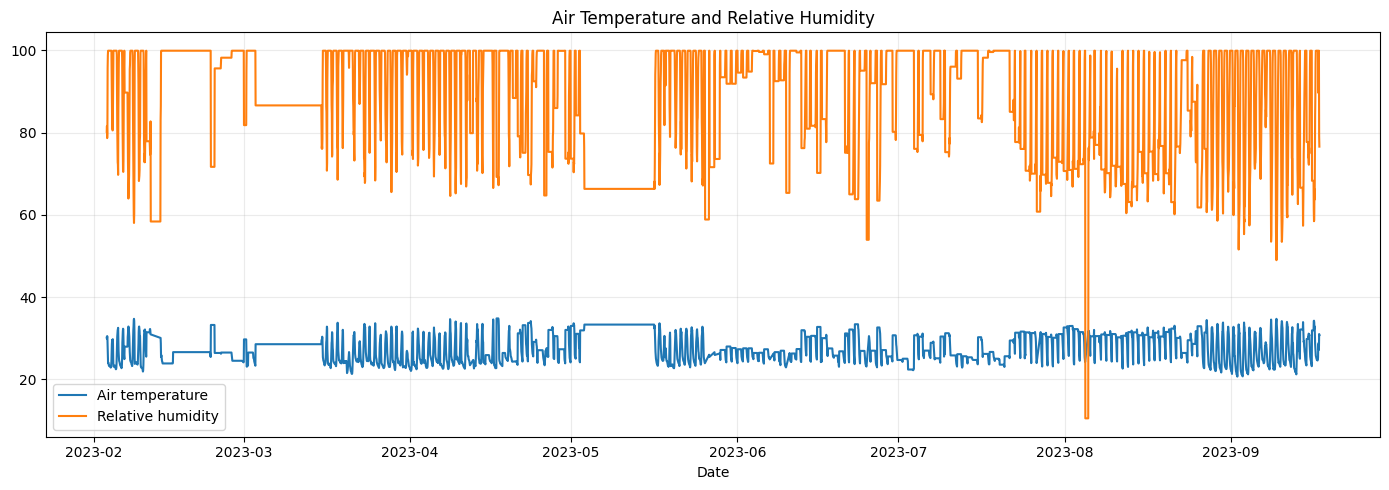

In [24]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["air_temp_c"],
    label="Air temperature"
)

plt.plot(
    df["timestamp"],
    df["humidity"],
    label="Relative humidity"
)

plt.title(
    "Air Temperature and Relative Humidity"
)
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Layer 1 vs Layer 2 scatterplots

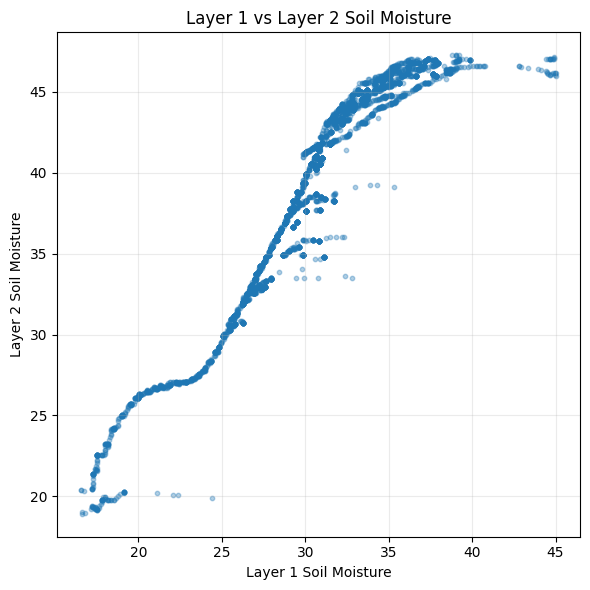

In [25]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df["soil_moisture_l1"],
    df["soil_moisture_l2"],
    s=10,
    alpha=0.35
)

plt.xlabel(
    "Layer 1 Soil Moisture"
)
plt.ylabel(
    "Layer 2 Soil Moisture"
)
plt.title(
    "Layer 1 vs Layer 2 Soil Moisture"
)
plt.tight_layout()
plt.show()

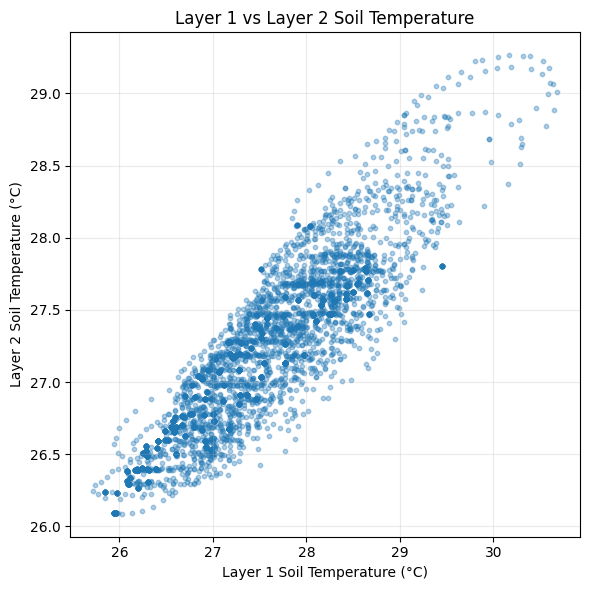

In [26]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df["soil_temp_l1_c"],
    df["soil_temp_l2_c"],
    s=10,
    alpha=0.35
)

plt.xlabel(
    "Layer 1 Soil Temperature (°C)"
)
plt.ylabel(
    "Layer 2 Soil Temperature (°C)"
)
plt.title(
    "Layer 1 vs Layer 2 Soil Temperature"
)
plt.tight_layout()
plt.show()

## 18. Depth-difference analysis

In [27]:
df["moisture_depth_difference"] = (
    df["soil_moisture_l1"]
    - df["soil_moisture_l2"]
)

df["temperature_depth_difference"] = (
    df["soil_temp_l1_c"]
    - df["soil_temp_l2_c"]
)

depth_stats = df[
    [
        "moisture_depth_difference",
        "temperature_depth_difference",
    ]
].describe().T

display(depth_stats.round(3))

,count,mean,std,min,25%,50%,75%,max
moisture_depth_difference,"5,426.000",-8.759,2.591,-12.330,-10.978,-9.660,-6.410,4.505
temperature_depth_difference,"5,426.000",0.295,0.407,-0.685,-0.066,0.205,0.580,1.788


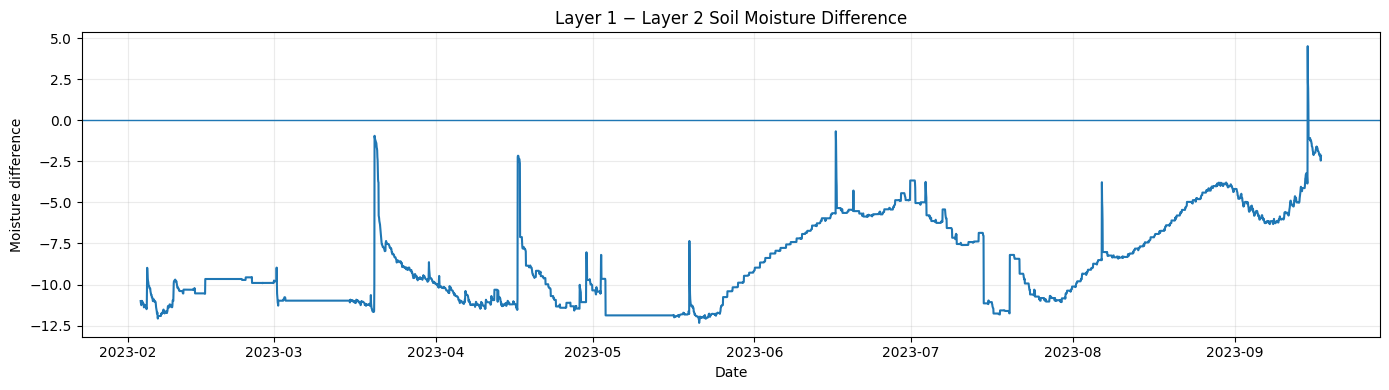

In [28]:
plt.figure(figsize=(14, 4))

plt.plot(
    df["timestamp"],
    df["moisture_depth_difference"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Layer 1 − Layer 2 Soil Moisture Difference"
)
plt.ylabel("Moisture difference")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

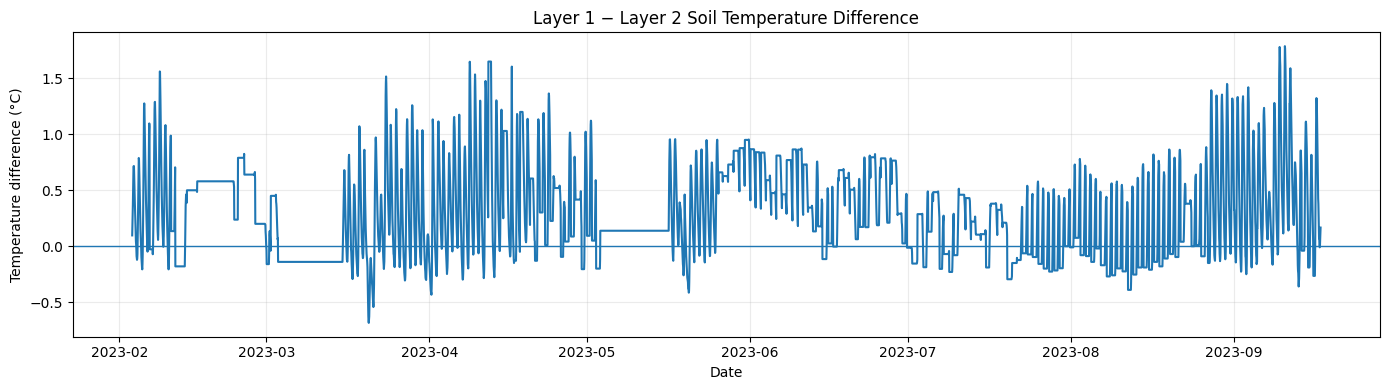

In [29]:
plt.figure(figsize=(14, 4))

plt.plot(
    df["timestamp"],
    df["temperature_depth_difference"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Layer 1 − Layer 2 Soil Temperature Difference"
)
plt.ylabel("Temperature difference (°C)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 19. Hour-of-day patterns

In [30]:
df["hour"] = df["timestamp"].dt.hour

hourly_means = (
    df.groupby("hour")[
        SENSOR_COLUMNS
    ]
    .mean()
)

display(hourly_means.round(3))

,air_temp_c,humidity,soil_moisture_l1,soil_temp_l1_c,soil_moisture_l2,soil_temp_l2_c
hour,,,,,,
0,26.994,88.797,30.422,27.439,39.172,27.233
2,27.204,88.034,30.400,27.381,39.157,27.208
3,27.305,87.278,30.364,27.330,39.151,27.185
5,27.299,87.105,30.379,27.293,39.158,27.170
6,27.743,87.008,30.409,27.260,39.156,27.154
8,28.557,85.525,30.393,27.225,39.149,27.137
9,29.328,81.960,30.365,27.212,39.128,27.119
11,29.896,79.645,30.353,27.234,39.130,27.102
12,29.794,79.827,30.367,27.366,39.145,27.095


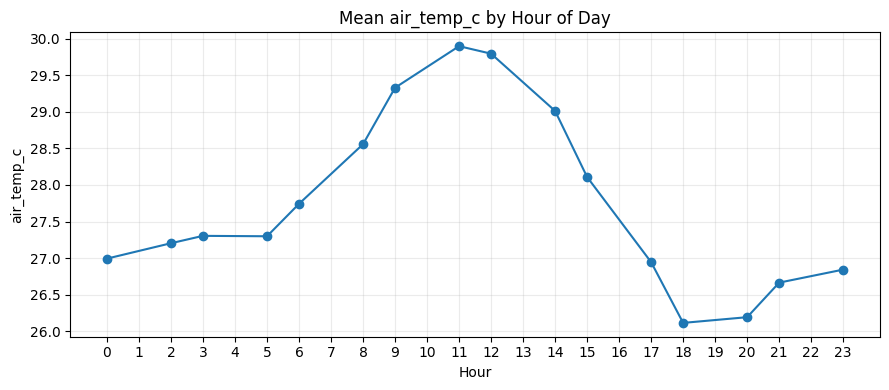

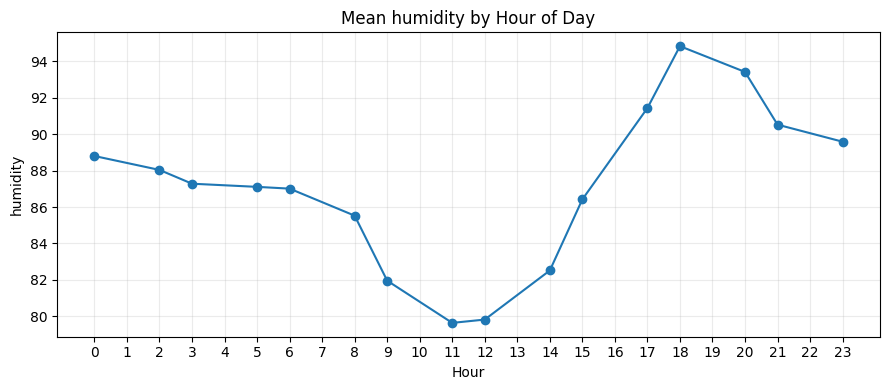

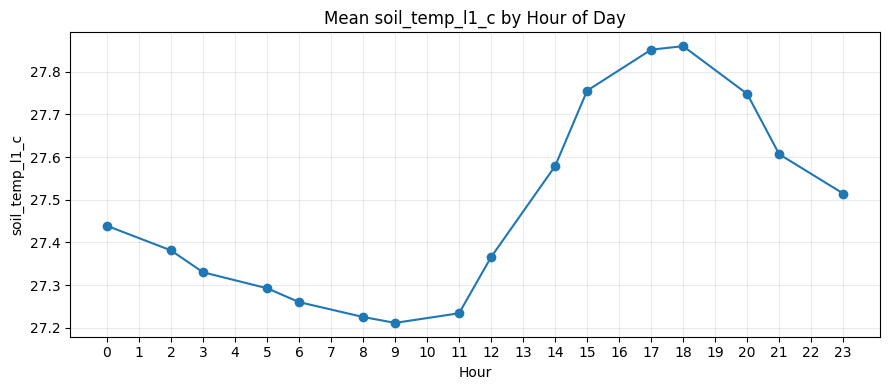

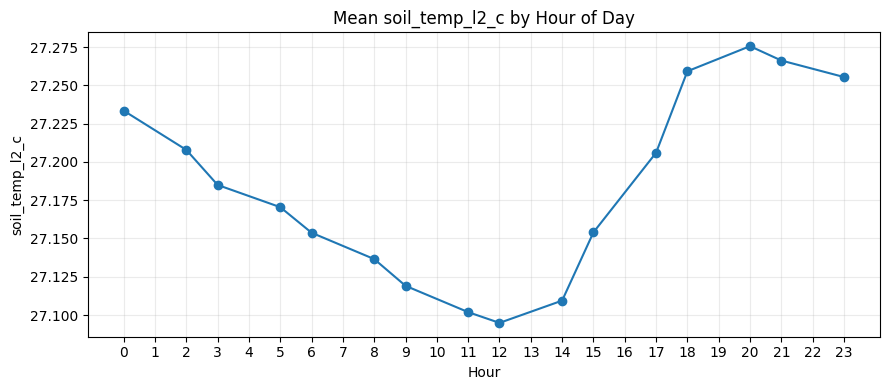

In [31]:
for col in [
    "air_temp_c",
    "humidity",
    "soil_temp_l1_c",
    "soil_temp_l2_c",
]:
    plt.figure(figsize=(9, 4))
    plt.plot(
        hourly_means.index,
        hourly_means[col],
        marker="o"
    )
    plt.xticks(range(0, 24))
    plt.title(
        f"Mean {col} by Hour of Day"
    )
    plt.xlabel("Hour")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 20. Monthly patterns

In [32]:
df["month"] = df["timestamp"].dt.month

monthly_means = (
    df.groupby("month")[
        SENSOR_COLUMNS
    ]
    .mean()
)

display(monthly_means.round(3))

,air_temp_c,humidity,soil_moisture_l1,soil_temp_l1_c,soil_moisture_l2,soil_temp_l2_c
month,,,,,,
2,26.769,92.509,31.733,27.300,41.974,26.870
3,26.867,91.603,33.158,27.109,43.131,27.023
4,26.956,91.724,34.957,27.829,45.352,27.381
5,29.741,79.095,32.213,27.804,43.535,27.493
6,27.394,90.105,27.300,28.014,33.652,27.525
7,27.395,89.030,32.210,26.661,40.873,26.579
8,29.385,77.120,27.353,26.965,34.102,26.804
9,26.915,86.579,19.565,28.723,24.305,28.248


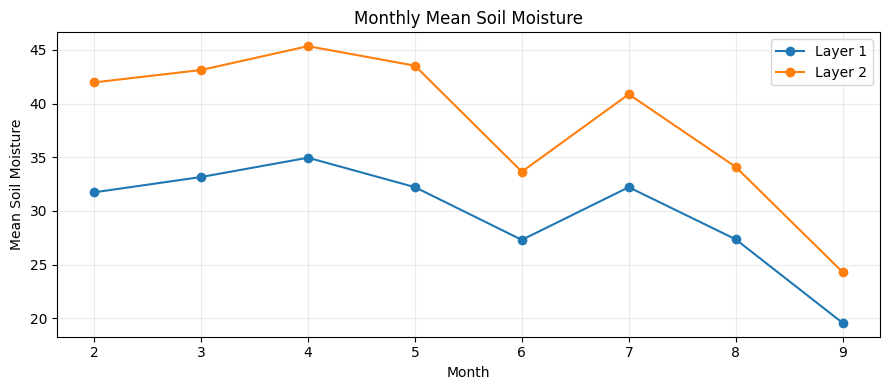

In [33]:
plt.figure(figsize=(9, 4))

plt.plot(
    monthly_means.index,
    monthly_means["soil_moisture_l1"],
    marker="o",
    label="Layer 1"
)

plt.plot(
    monthly_means.index,
    monthly_means["soil_moisture_l2"],
    marker="o",
    label="Layer 2"
)

plt.xlabel("Month")
plt.ylabel("Mean Soil Moisture")
plt.title(
    "Monthly Mean Soil Moisture"
)
plt.legend()
plt.tight_layout()
plt.show()

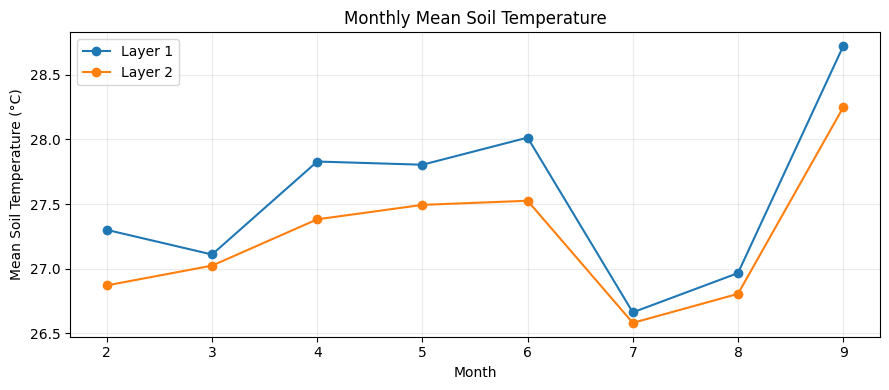

In [34]:
plt.figure(figsize=(9, 4))

plt.plot(
    monthly_means.index,
    monthly_means["soil_temp_l1_c"],
    marker="o",
    label="Layer 1"
)

plt.plot(
    monthly_means.index,
    monthly_means["soil_temp_l2_c"],
    marker="o",
    label="Layer 2"
)

plt.xlabel("Month")
plt.ylabel("Mean Soil Temperature (°C)")
plt.title(
    "Monthly Mean Soil Temperature"
)
plt.legend()
plt.tight_layout()
plt.show()

## 21. Daily aggregation

In [35]:
daily = (
    df.set_index("timestamp")[
        SENSOR_COLUMNS
    ]
    .resample("D")
    .mean()
)

display(daily.head())
print("Daily rows:", len(daily))

,air_temp_c,humidity,soil_moisture_l1,soil_temp_l1_c,soil_moisture_l2,soil_temp_l2_c
timestamp,,,,,,
2023-02-03,26.008,93.387,35.474,26.935,46.582,26.454
2023-02-04,24.936,95.350,35.520,26.697,46.310,26.435
2023-02-05,25.962,93.100,35.716,26.913,46.275,26.510
2023-02-06,26.558,91.081,34.313,27.026,45.785,26.716
2023-02-07,28.431,85.385,32.841,27.227,44.616,26.780


Daily rows: 227


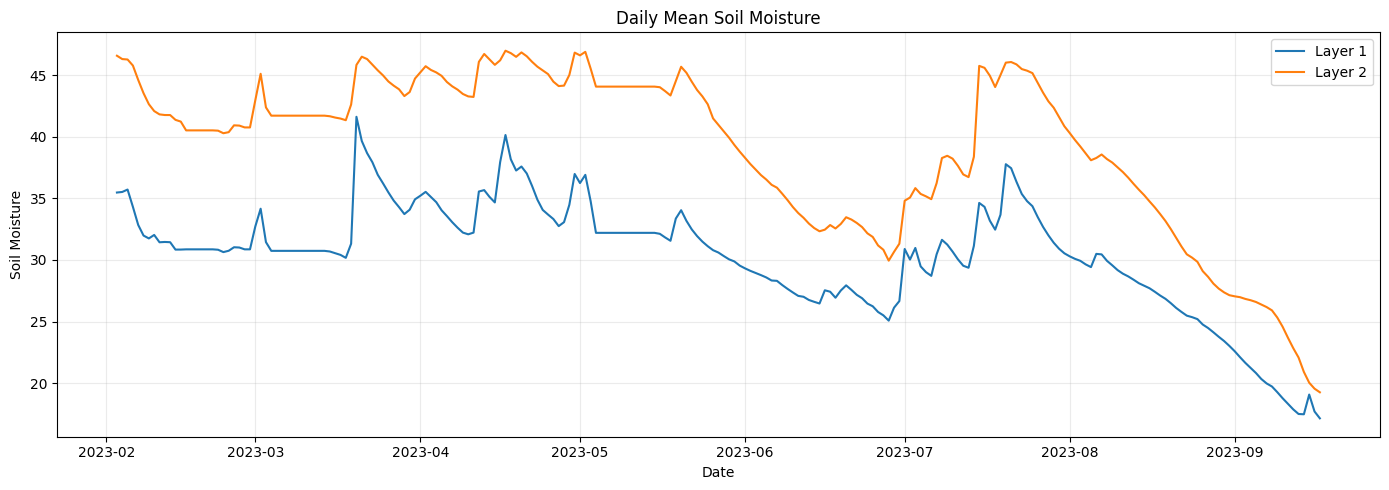

In [36]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily.index,
    daily["soil_moisture_l1"],
    label="Layer 1"
)

plt.plot(
    daily.index,
    daily["soil_moisture_l2"],
    label="Layer 2"
)

plt.title(
    "Daily Mean Soil Moisture"
)
plt.xlabel("Date")
plt.ylabel("Soil Moisture")
plt.legend()
plt.tight_layout()
plt.show()

## 22. Rate-of-change analysis

Large changes between consecutive hourly observations can indicate:
- abrupt environmental change,
- rainfall/watering response,
- sensor disturbance,
- or potential anomalous behaviour.

These values are explored here but not removed.

In [37]:
CHANGE_COLUMNS = [
    "air_temp_c",
    "humidity",
    "soil_moisture_l1",
    "soil_temp_l1_c",
    "soil_moisture_l2",
    "soil_temp_l2_c",
]

change_df = pd.DataFrame({
    "timestamp": df["timestamp"]
})

for col in CHANGE_COLUMNS:
    change_df[f"{col}_change_1h"] = (
        df[col].diff()
    )

display(
    change_df.describe().T.round(3)
)

,count,mean,min,25%,50%,75%,max,std
timestamp,5426,2023-05-27 11:29:59.999666944,2023-02-03 11:00:00,2023-03-31 23:15:00,2023-05-27 11:30:00,2023-07-22 23:45:00,2023-09-17 12:00:00,NaN
air_temp_c_change_1h,"5,425.000",0.000,-7.320,-0.170,0.000,0.000,12.100,1.146
humidity_change_1h,"5,425.000",-0.001,-89.400,0.000,0.000,0.000,61.300,4.897
soil_moisture_l1_change_1h,"5,425.000",-0.003,-5.014,-0.005,0.000,0.000,9.445,0.357
soil_temp_l1_c_change_1h,"5,425.000",0.000,-1.318,-0.010,0.000,0.000,1.501,0.140
soil_moisture_l2_change_1h,"5,425.000",-0.005,-3.195,-0.003,0.000,0.000,8.058,0.198
soil_temp_l2_c_change_1h,"5,425.000",0.000,-0.467,0.000,0.000,0.002,0.408,0.048


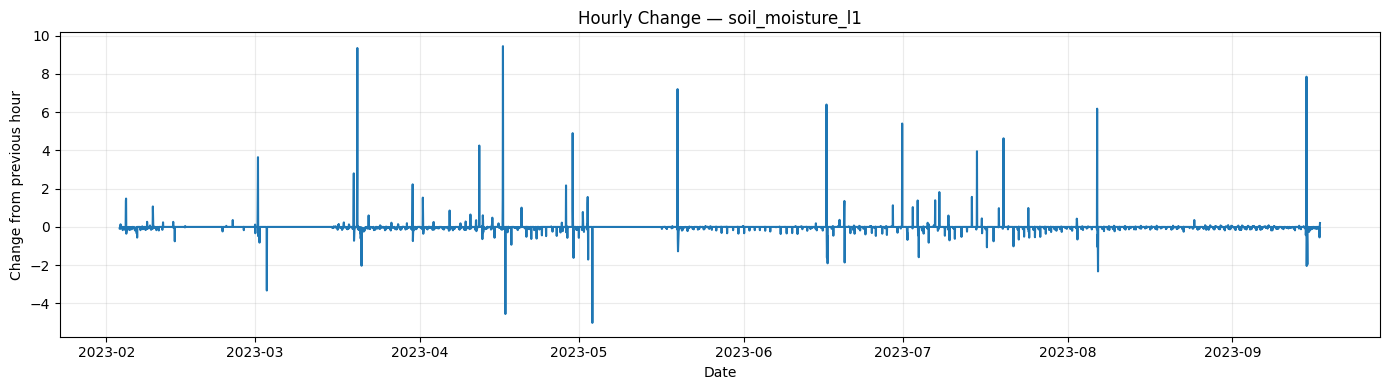

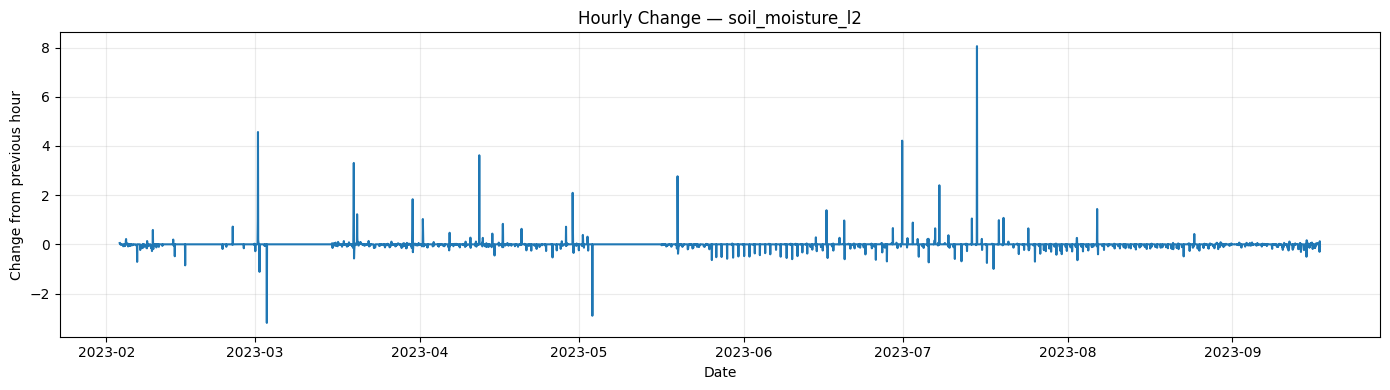

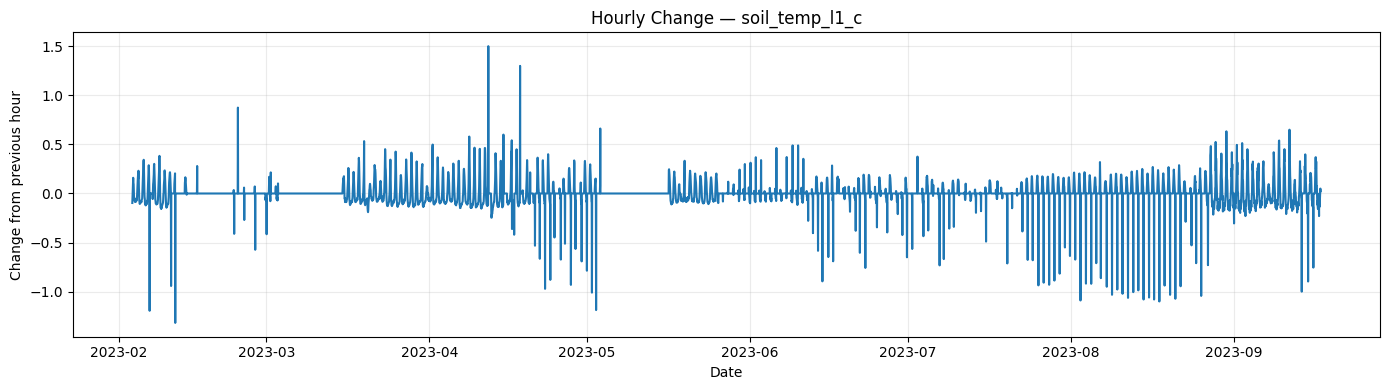

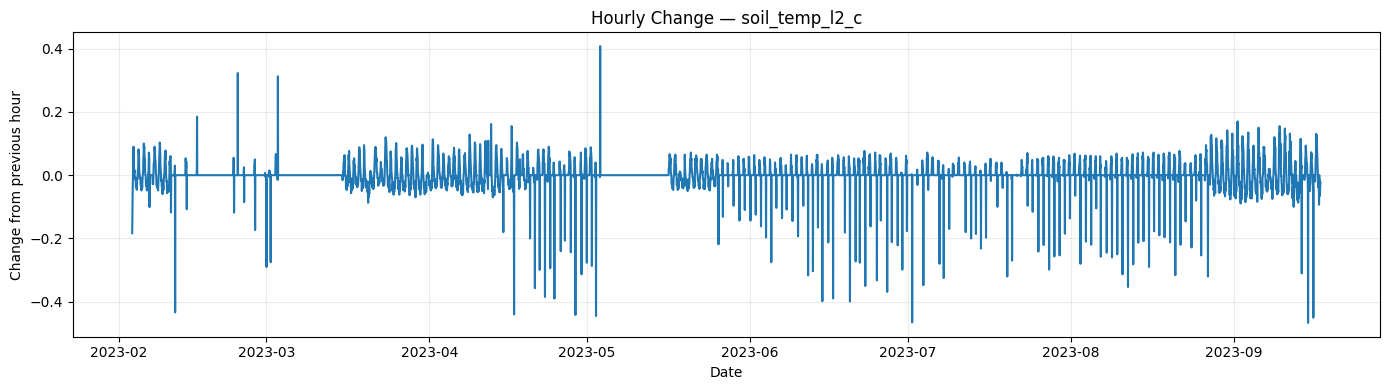

In [38]:
for col in [
    "soil_moisture_l1",
    "soil_moisture_l2",
    "soil_temp_l1_c",
    "soil_temp_l2_c",
]:
    change_col = f"{col}_change_1h"

    plt.figure(figsize=(14, 4))
    plt.plot(
        change_df["timestamp"],
        change_df[change_col]
    )
    plt.title(
        f"Hourly Change — {col}"
    )
    plt.ylabel("Change from previous hour")
    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

## 23. Rolling statistics

In [39]:
# 24-hour rolling window
rolling_window = 24

rolling = pd.DataFrame({
    "timestamp": df["timestamp"]
})

for col in SENSOR_COLUMNS:
    rolling[f"{col}_mean_24h"] = (
        df[col]
        .rolling(
            rolling_window,
            min_periods=1
        )
        .mean()
    )

    rolling[f"{col}_std_24h"] = (
        df[col]
        .rolling(
            rolling_window,
            min_periods=2
        )
        .std()
    )

display(
    rolling.head()
)

,timestamp,air_temp_c_mean_24h,air_temp_c_std_24h,humidity_mean_24h,humidity_std_24h,soil_moisture_l1_mean_24h,soil_moisture_l1_std_24h,soil_temp_l1_c_mean_24h,soil_temp_l1_c_std_24h,soil_moisture_l2_mean_24h,soil_moisture_l2_std_24h,soil_temp_l2_c_mean_24h,soil_temp_l2_c_std_24h
0,2023-02-03 11:00:00.000,30.130,NaN,80.170,NaN,35.483,NaN,26.777,NaN,46.483,NaN,26.680,NaN
1,2023-02-03 12:00:00.000,29.980,0.212,80.885,1.011,35.447,0.052,26.728,0.068,46.508,0.035,26.588,0.130
2,2023-02-03 12:59:59.999,30.153,0.336,80.140,1.475,35.431,0.046,26.702,0.066,46.526,0.040,26.524,0.145
3,2023-02-03 14:00:00.000,30.163,0.275,80.080,1.210,35.401,0.071,26.701,0.054,46.536,0.038,26.476,0.152
4,2023-02-03 15:00:00.000,29.694,1.074,83.190,7.033,35.398,0.062,26.724,0.069,46.547,0.041,26.445,0.149


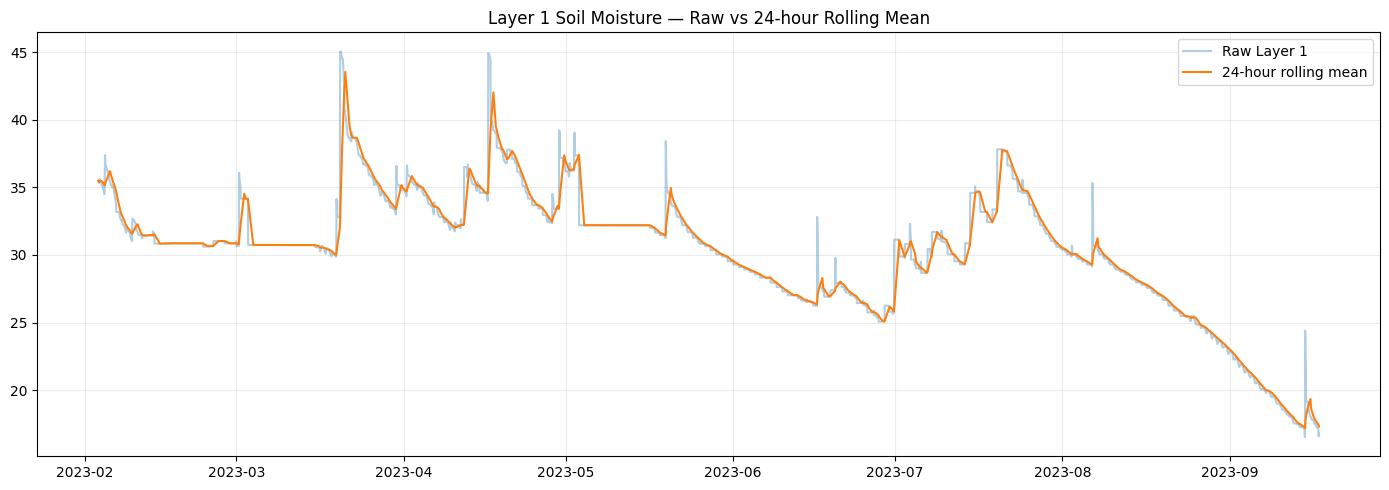

In [40]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["timestamp"],
    df["soil_moisture_l1"],
    alpha=0.35,
    label="Raw Layer 1"
)

plt.plot(
    rolling["timestamp"],
    rolling[
        "soil_moisture_l1_mean_24h"
    ],
    label="24-hour rolling mean"
)

plt.title(
    "Layer 1 Soil Moisture — Raw vs 24-hour Rolling Mean"
)
plt.legend()
plt.tight_layout()
plt.show()

## 24. Simple anomaly-oriented z-score diagnostics

In [41]:
# This is only an exploratory diagnostic.
# It is NOT the final anomaly-detection model.

zscore_summary = []

for col in SENSOR_COLUMNS:
    mean = df[col].mean()
    std = df[col].std()

    z = (
        (df[col] - mean)
        / std
    )

    extreme = (
        z.abs() > 3
    )

    zscore_summary.append({
        "feature": col,
        "abs_z_gt_3_count": int(extreme.sum()),
        "abs_z_gt_3_percent": extreme.mean() * 100,
    })

zscore_summary = pd.DataFrame(
    zscore_summary
)

display(
    zscore_summary.round(3)
)

,feature,abs_z_gt_3_count,abs_z_gt_3_percent
0,air_temp_c,0,0.000
1,humidity,14,0.258
2,soil_moisture_l1,29,0.534
3,soil_temp_l1_c,31,0.571
4,soil_moisture_l2,25,0.461
5,soil_temp_l2_c,48,0.885


## 25. Inspect the most extreme observations

In [42]:
# Show timestamps with very large 1-hour soil-moisture changes.

temp = df[
    [
        "timestamp",
        "soil_moisture_l1",
        "soil_moisture_l2",
    ]
].copy()

temp["l1_change"] = (
    temp["soil_moisture_l1"]
    .diff()
)

temp["l2_change"] = (
    temp["soil_moisture_l2"]
    .diff()
)

temp["max_abs_change"] = np.maximum(
    temp["l1_change"].abs(),
    temp["l2_change"].abs()
)

display(
    temp.sort_values(
        "max_abs_change",
        ascending=False
    ).head(20)
)

,timestamp,soil_moisture_l1,soil_moisture_l2,l1_change,l2_change,max_abs_change
1733,2023-04-16 15:59:59.999,44.935,47.177,9.445,0.833,9.445
1075,2023-03-20 06:00:00.000,45.042,45.990,9.348,0.252,9.348
3875,2023-07-14 21:59:59.999,34.596,45.738,3.954,8.058,8.058
5364,2023-09-14 23:00:00.000,24.400,19.895,7.850,-0.505,7.850
2522,2023-05-19 12:59:59.999,38.430,45.777,7.200,2.767,7.200
3195,2023-06-16 14:00:00.000,32.812,33.487,6.395,1.385,6.395
4418,2023-08-06 12:59:59.999,35.328,39.102,6.178,1.437,6.178
3537,2023-06-30 20:00:00.000,31.133,34.800,5.403,4.215,5.403
2137,2023-05-03 12:00:00.000,32.200,44.073,-5.014,-2.905,5.014
2048,2023-04-29 18:59:59.999,38.320,46.582,4.900,2.093,4.900


## 26. Autocorrelation at useful hourly lags

In [43]:
# Useful for understanding temporal memory before LSTM sequence design.

lags = [
    1,      # 1 hour
    3,      # 3 hours
    6,      # 6 hours
    12,     # 12 hours
    24,     # 1 day
    48,     # 2 days
    72,     # 3 days
    168,    # 1 week
]

autocorr_rows = []

for col in SENSOR_COLUMNS:
    row = {
        "feature": col
    }

    for lag in lags:
        row[f"lag_{lag}h"] = (
            df[col]
            .autocorr(
                lag=lag
            )
        )

    autocorr_rows.append(row)

autocorr_table = pd.DataFrame(
    autocorr_rows
)

display(
    autocorr_table.round(3)
)

autocorr_table.to_csv(
    RESULTS_DIR
    / "autocorrelation_summary.csv",
    index=False
)

,feature,lag_1h,lag_3h,lag_6h,lag_12h,lag_24h,lag_48h,lag_72h,lag_168h
0,air_temp_c,0.940,0.743,0.447,0.207,0.688,0.589,0.506,0.423
1,humidity,0.939,0.758,0.525,0.338,0.636,0.524,0.470,0.359
2,soil_moisture_l1,0.997,0.990,0.982,0.968,0.945,0.906,0.872,0.768
3,soil_temp_l1_c,0.985,0.922,0.797,0.658,0.855,0.794,0.740,0.660
4,soil_moisture_l2,1.000,0.998,0.997,0.994,0.988,0.972,0.957,0.893
5,soil_temp_l2_c,0.996,0.981,0.953,0.913,0.934,0.880,0.833,0.750


## 27. Chronological train / validation / test split

The dataset is a time series, so use a **chronological split**, not a random split.

Recommended:
- first 70% → training
- next 15% → validation
- final 15% → testing

In [44]:
n = len(df)

train_end = int(
    n * 0.70
)

val_end = int(
    n * 0.85
)

train_df = df.iloc[
    :train_end
].copy()

validation_df = df.iloc[
    train_end:val_end
].copy()

test_df = df.iloc[
    val_end:
].copy()

split_summary = pd.DataFrame({
    "split": [
        "Train",
        "Validation",
        "Test",
    ],
    "rows": [
        len(train_df),
        len(validation_df),
        len(test_df),
    ],
    "start": [
        train_df["timestamp"].min(),
        validation_df["timestamp"].min(),
        test_df["timestamp"].min(),
    ],
    "end": [
        train_df["timestamp"].max(),
        validation_df["timestamp"].max(),
        test_df["timestamp"].max(),
    ],
})

display(
    split_summary
)

,split,rows,start,end
0,Train,3798,2023-02-03 11:00:00,2023-07-11 15:59:59.999
1,Validation,814,2023-07-11 17:00:00,2023-08-14 14:00:00.000
2,Test,814,2023-08-14 15:00:00,2023-09-17 12:00:00.000


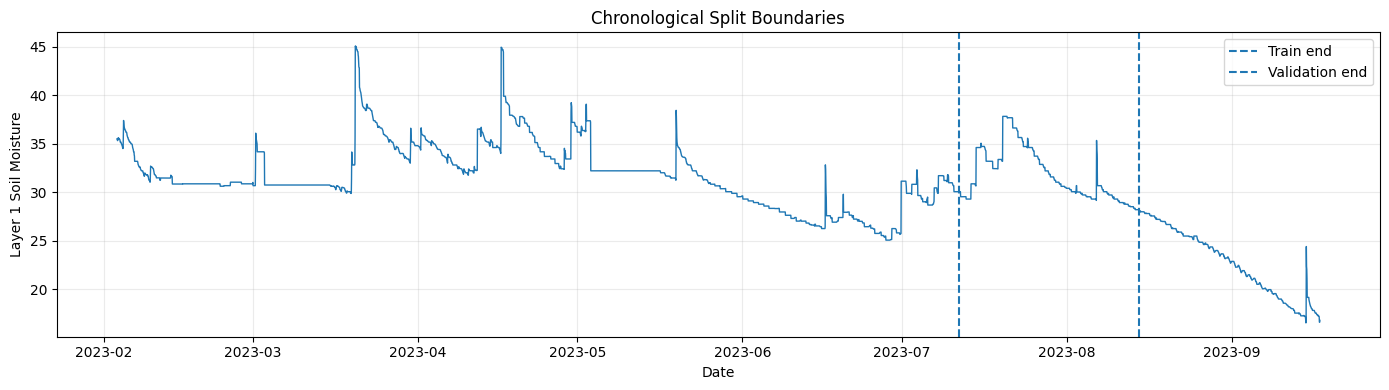

In [45]:
plt.figure(figsize=(14, 4))

plt.plot(
    df["timestamp"],
    df["soil_moisture_l1"],
    linewidth=1
)

plt.axvline(
    train_df["timestamp"].max(),
    linestyle="--",
    label="Train end"
)

plt.axvline(
    validation_df["timestamp"].max(),
    linestyle="--",
    label="Validation end"
)

plt.title(
    "Chronological Split Boundaries"
)
plt.ylabel(
    "Layer 1 Soil Moisture"
)
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

## 28. Build the generic four-feature representation

This previews the format that will later be created formally in `build_generic_dataset.py`.

Each depth becomes an independent soil-condition stream with the same four model features:

- `air_temperature`
- `relative_humidity`
- `soil_temperature`
- `soil_moisture`

`depth_source` is kept for tracking and evaluation, but it does **not have to be supplied to the anomaly model**.

In [46]:
layer_1 = pd.DataFrame({
    "timestamp": df["timestamp"],
    "air_temperature": df["air_temp_c"],
    "relative_humidity": df["humidity"],
    "soil_temperature": df["soil_temp_l1_c"],
    "soil_moisture": df["soil_moisture_l1"],
    "depth_source": "layer_1",
})

layer_2 = pd.DataFrame({
    "timestamp": df["timestamp"],
    "air_temperature": df["air_temp_c"],
    "relative_humidity": df["humidity"],
    "soil_temperature": df["soil_temp_l2_c"],
    "soil_moisture": df["soil_moisture_l2"],
    "depth_source": "layer_2",
})

generic_df = pd.concat(
    [
        layer_1,
        layer_2,
    ],
    ignore_index=True
)

display(
    generic_df.head(10)
)

print(
    "Generic dataset rows:",
    len(generic_df)
)

print()
print(
    generic_df["depth_source"]
    .value_counts()
)

,timestamp,air_temperature,relative_humidity,soil_temperature,soil_moisture,depth_source
0,2023-02-03 11:00:00.000,30.130,80.170,26.777,35.483,layer_1
1,2023-02-03 12:00:00.000,29.830,81.600,26.680,35.410,layer_1
2,2023-02-03 12:59:59.999,30.500,78.650,26.650,35.400,layer_1
3,2023-02-03 14:00:00.000,30.190,79.900,26.698,35.310,layer_1
4,2023-02-03 15:00:00.000,27.820,95.630,26.815,35.388,layer_1
5,2023-02-03 15:59:59.999,24.470,98.780,26.975,35.527,layer_1
6,2023-02-03 17:00:00.000,23.900,99.900,27.080,35.610,layer_1
7,2023-02-03 18:00:00.000,24.000,99.900,27.176,35.564,layer_1
8,2023-02-03 18:59:59.999,24.000,99.900,27.176,35.564,layer_1
9,2023-02-03 20:00:00.000,23.480,99.900,27.122,35.500,layer_1


Generic dataset rows: 10852

depth_source
layer_1    5426
layer_2    5426
Name: count, dtype: int64


## 29. Important LSTM note

For the LSTM Autoencoder, **do not create a sequence that switches between layers**.

Correct:

```text
Layer 1:
t1 → t2 → t3 → ... → t24

Layer 2:
t1 → t2 → t3 → ... → t24
```

Incorrect:

```text
Layer1_t1 → Layer2_t1 → Layer1_t2 → Layer2_t2 ...
```

A starting sequence length of **24 hours** is reasonable because the dataset is hourly.  
Later, hyperparameter tuning can compare sequence lengths such as:

```text
12 hours
24 hours
48 hours
72 hours
```

## 30. EDA summary table

In [47]:
eda_summary = pd.DataFrame({
    "metric": [
        "Total rows",
        "Start timestamp",
        "End timestamp",
        "Duplicate timestamps",
        "Missing sensor values",
        "Median sampling interval (hours)",
        "Layer 1 moisture mean",
        "Layer 2 moisture mean",
        "Layer 1 soil temperature mean",
        "Layer 2 soil temperature mean",
    ],
    "value": [
        len(df),
        df["timestamp"].min(),
        df["timestamp"].max(),
        int(df["timestamp"].duplicated().sum()),
        int(df[SENSOR_COLUMNS].isna().sum().sum()),
        time_diff_hours.median(),
        df["soil_moisture_l1"].mean(),
        df["soil_moisture_l2"].mean(),
        df["soil_temp_l1_c"].mean(),
        df["soil_temp_l2_c"].mean(),
    ],
})

display(
    eda_summary
)

eda_summary.to_csv(
    RESULTS_DIR
    / "eda_summary.csv",
    index=False
)

,metric,value
0,Total rows,5426
1,Start timestamp,2023-02-03 11:00:00
2,End timestamp,2023-09-17 12:00:00
3,Duplicate timestamps,0
4,Missing sensor values,0
5,Median sampling interval (hours),1.000
6,Layer 1 moisture mean,30.408
7,Layer 2 moisture mean,39.168
8,Layer 1 soil temperature mean,27.478
9,Layer 2 soil temperature mean,27.183


# Final interpretation checklist

After running the notebook, record the following findings for your report:

1. **Dataset size and monitoring period**
2. **Whether the hourly sampling interval is continuous**
3. **Missing-value and duplicate counts**
4. **Typical ranges of air temperature and humidity**
5. **Typical Layer 1 and Layer 2 soil-moisture values**
6. **Typical Layer 1 and Layer 2 soil-temperature values**
7. **Strength of correlations between the two soil layers**
8. **Average and extreme depth differences**
9. **Daily/hourly patterns**
10. **Largest hourly changes**
11. **Autocorrelation at 1 h, 24 h and 168 h**
12. **Evidence supporting the chosen LSTM sequence length**
13. **Chronological train/validation/test dates**

## Next ML workflow

```text
EDA.ipynb
    ↓
preprocess.py
    ↓
build_generic_dataset.py
    ↓
feature_engineering.py
    ↓
hyperparameter_tuning.py
    ↓
Isolation Forest
Dense Autoencoder
LSTM Autoencoder
    ↓
evaluate_models.py
    ↓
select_best_model.py
    ↓
predict_anomaly.py
```

Do not remove unusual observations just because they appear as IQR or z-score extremes.  
For an anomaly-detection project, those observations may contain exactly the behaviour the models need to identify.